In [213]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense,MaxPooling2D,BatchNormalization,Dropout
from tensorflow.keras.models import Sequential

In [214]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [215]:
df = pd.read_csv(f'{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [216]:
df.shape

(7043, 21)

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [218]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [219]:
df.duplicated().sum()

np.int64(0)

In [220]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [221]:
df = df.drop(columns=['customerID'])

In [222]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [224]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [225]:
df = df.dropna()

<Axes: >

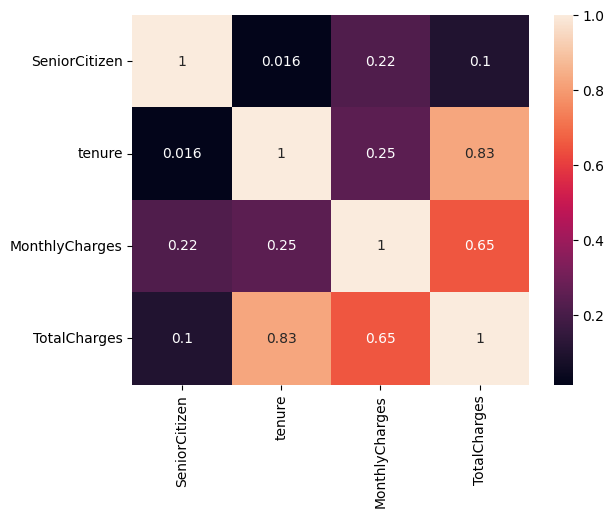

In [226]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

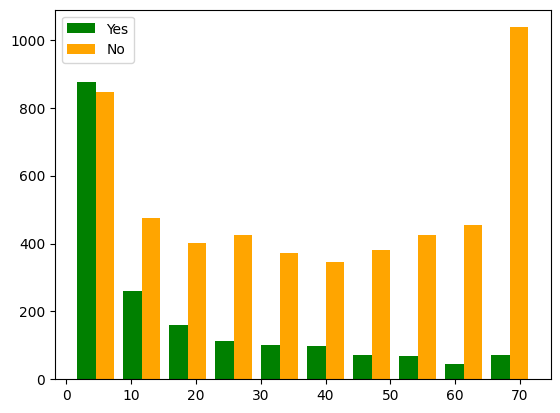

In [227]:
tenure_yes = df[df['Churn'] == 'Yes'].tenure
tenure_no =  df[df['Churn'] == 'No'].tenure
plt.hist([tenure_yes,tenure_no],color=['green','orange'],label=['Yes','No'])
plt.legend()

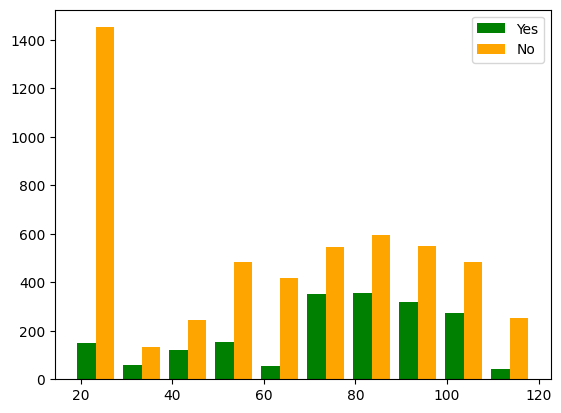

In [228]:
tenure_yes = df[df['Churn'] == 'Yes'].MonthlyCharges
tenure_no =  df[df['Churn'] == 'No'].MonthlyCharges
plt.hist([tenure_yes,tenure_no],color=['green','orange'],label=['Yes','No'])
plt.legend()

In [229]:
def yes_no_Cols(df):
  for column in df:
    if df[column].dtypes == 'object':
      print(f'{column}-> {df[column].unique()}')

In [230]:
yes_no_Cols(df)

gender-> ['Female' 'Male']
Partner-> ['Yes' 'No']
Dependents-> ['No' 'Yes']
PhoneService-> ['No' 'Yes']
MultipleLines-> ['No phone service' 'No' 'Yes']
InternetService-> ['DSL' 'Fiber optic' 'No']
OnlineSecurity-> ['No' 'Yes' 'No internet service']
OnlineBackup-> ['Yes' 'No' 'No internet service']
DeviceProtection-> ['No' 'Yes' 'No internet service']
TechSupport-> ['No' 'Yes' 'No internet service']
StreamingTV-> ['No' 'Yes' 'No internet service']
StreamingMovies-> ['No' 'Yes' 'No internet service']
Contract-> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling-> ['Yes' 'No']
PaymentMethod-> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn-> ['No' 'Yes']


In [231]:
df = df.replace('NO','No')
df = df.replace('No phone service','No')

In [232]:
yes_no_col = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']

In [233]:
label_encoding = LabelEncoder()

In [234]:
len(yes_no_col)

12

In [235]:
for col in yes_no_col:
  df[col] = df[col].replace({'Yes':1,'No':0, 'No internet service':0})

/tmp/ipykernel_4468/3987556420.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes':1,'No':0, 'No internet service':0})


In [236]:
df['gender'] = label_encoding.fit_transform(df['gender'])

In [237]:
yes_no_Cols(df)

InternetService-> ['DSL' 'Fiber optic' 'No']
Contract-> ['Month-to-month' 'One year' 'Two year']
PaymentMethod-> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [238]:
df = pd.get_dummies(data=df,columns=['InternetService','Contract','PaymentMethod'],dtype=int)

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7032 non-null   int64  
 1   SeniorCitizen                            7032 non-null   int64  
 2   Partner                                  7032 non-null   int64  
 3   Dependents                               7032 non-null   int64  
 4   tenure                                   7032 non-null   int64  
 5   PhoneService                             7032 non-null   int64  
 6   MultipleLines                            7032 non-null   int64  
 7   OnlineSecurity                           7032 non-null   int64  
 8   OnlineBackup                             7032 non-null   int64  
 9   DeviceProtection                         7032 non-null   int64  
 10  TechSupport                              7032 non-nul

In [240]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [241]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [242]:
X = df.drop(columns = ['Churn'],axis = 1)
y = df['Churn']

In [243]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [251]:

model = Sequential([
    Dense(16,activation='relu',input_shape = (26,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [252]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [253]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [254]:

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6542 - loss: 0.6929 - val_accuracy: 0.7556 - val_loss: 0.5029
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7433 - loss: 0.5406 - val_accuracy: 0.7822 - val_loss: 0.4420
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7589 - loss: 0.5071 - val_accuracy: 0.8027 - val_loss: 0.4225
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7591 - loss: 0.4932 - val_accuracy: 0.8018 - val_loss: 0.4149
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7673 - loss: 0.4744 - val_accuracy: 0.8080 - val_loss: 0.4115
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7780 - loss: 0.4673 - val_accuracy: 0.8009 - val_loss: 0.4106
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7736 - loss: 0.4576 - val_accuracy: 0.7982 - val_loss: 0.4103
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7813 - loss: 0.4576 - val_acc

In [255]:
test_results = model.evaluate(X_test, y_test)
print(test_results)


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7825 - loss: 0.4363
[0.43629151582717896, 0.7825160026550293]
